<a href="https://colab.research.google.com/github/Lakshmi-krishna-vr/Computational_Optimization_Lab/blob/main/Classification_of_MNIST_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Libraries

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import matplotlib.gridspec as gridspec

## Data Preprocessing & Visualization

Loading Fashion-MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


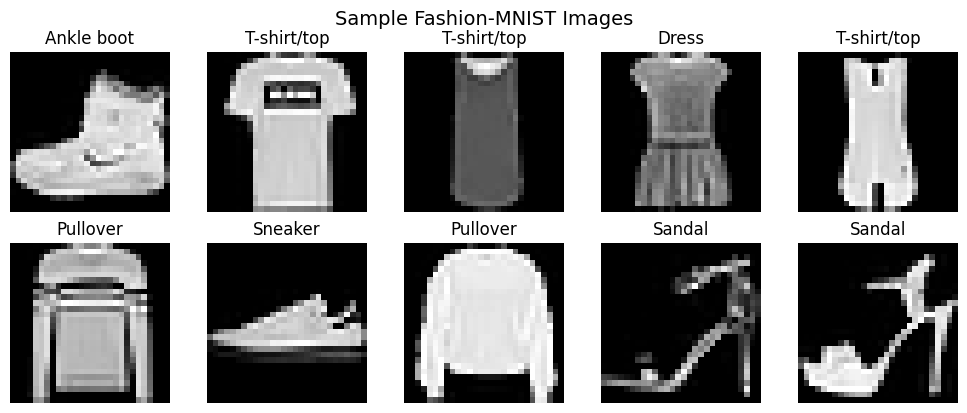

In [2]:
# Step 2: Load and preprocess Fashion-MNIST dataset
print("Loading Fashion-MNIST dataset...")
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize pixel values to [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Reshape images to add channel dimension (28, 28, 1)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)

print(f"Training data shape: {train_images.shape}")
print(f"Test data shape: {test_images.shape}")

# Step 3: Display sample images from the dataset
def display_sample_images(images, labels, num_rows=2, num_cols=5):
    plt.figure(figsize=(10, 4))
    for i in range(num_rows * num_cols):
        plt.subplot(num_rows, num_cols, i+1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.tight_layout()
    plt.suptitle('Sample Fashion-MNIST Images', y=1.02, fontsize=14)
    plt.show()

display_sample_images(train_images, train_labels)

## Model Creation

In [3]:
# Step 4: Build the CNN model using Functional API
def create_cnn_functional_model():
    # Define input layer
    inputs = keras.Input(shape=(28, 28, 1), name='input')

    # First Convolutional Block
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1')(inputs)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)

    # Second Convolutional Block
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)

    # Third Convolutional Block
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)

    # Flatten and Dense layers
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.5, name='dropout')(x)
    outputs = layers.Dense(10, activation='softmax', name='output')(x)

    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs, name='fashion_cnn')
    return model

# Create the model
model = create_cnn_functional_model()
model.summary()

Model: "fashion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

## Training and Evaluation


Training the model...

Test accuracy: 0.8928


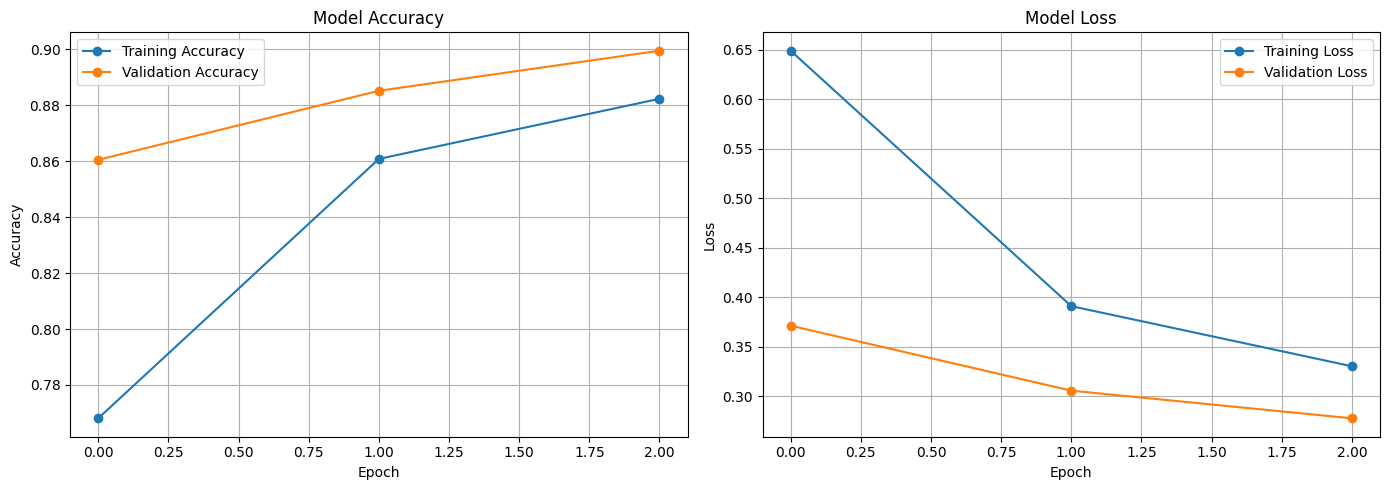

In [4]:
# Step 5: Compile and train the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\nTraining the model...")
history = model.fit(train_images, train_labels,
                    epochs=3,  # Reduced epochs for faster execution
                    batch_size=64,
                    validation_split=0.2,
                    verbose=0) # Set to 1 if you want to see the progress bar

# Step 6: Evaluate the model
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"\nTest accuracy: {test_accuracy:.4f}")

# Step 12: Training history visualization (Moved up slightly for flow)
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # Accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    # Loss
    ax2.plot(history.history['loss'], label='Training Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

plot_training_history(history)

## X-Raying the Model: Feature Extraction


FEATURE HIERARCHY DEMONSTRATION

Image 3642: True class = Sneaker
Predicted: Sneaker (confidence: 0.999)


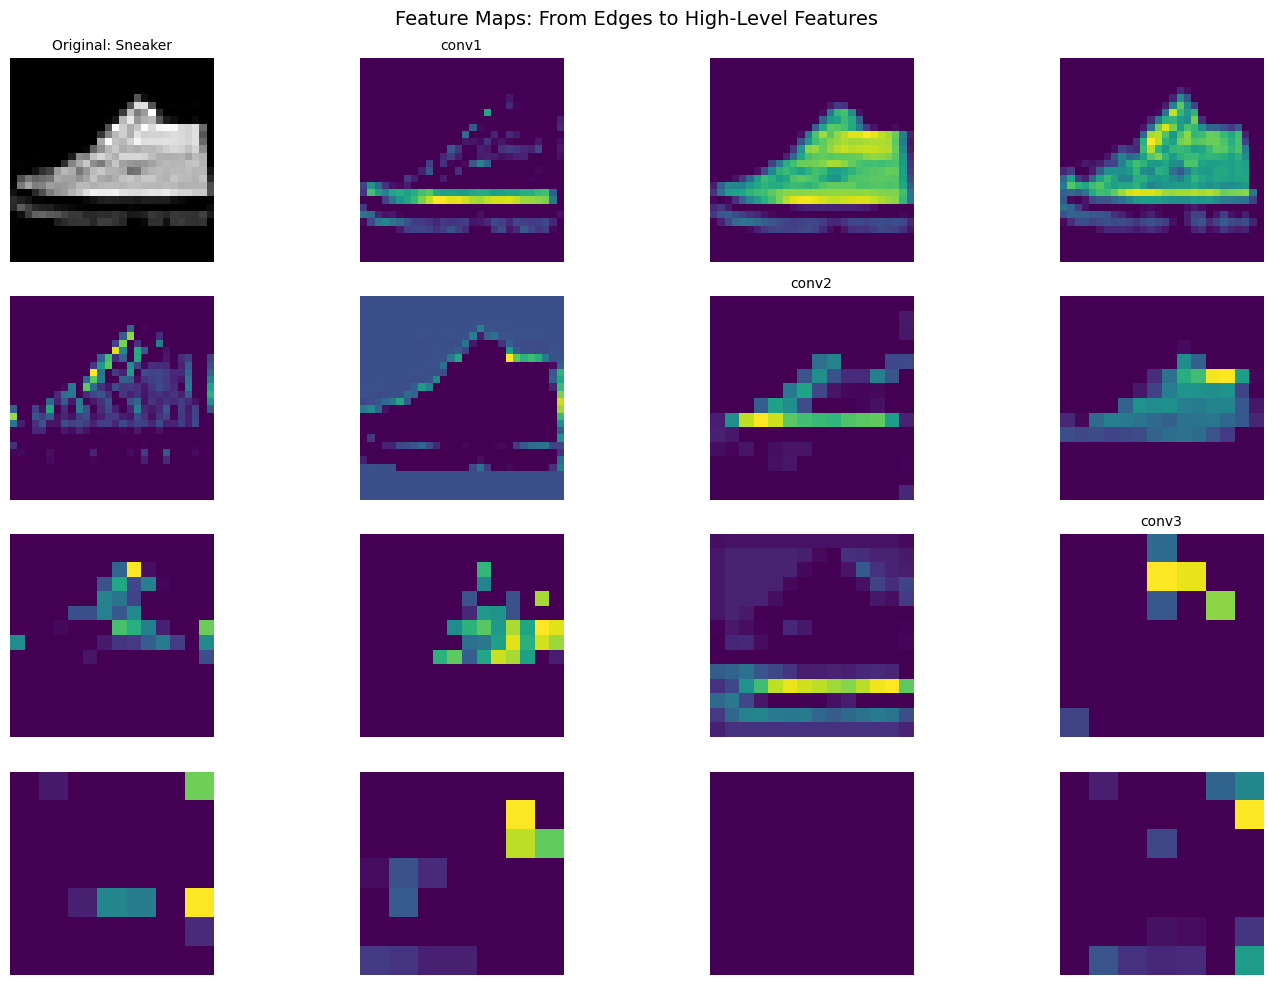


Image 2941: True class = Sneaker
Predicted: Sneaker (confidence: 0.993)


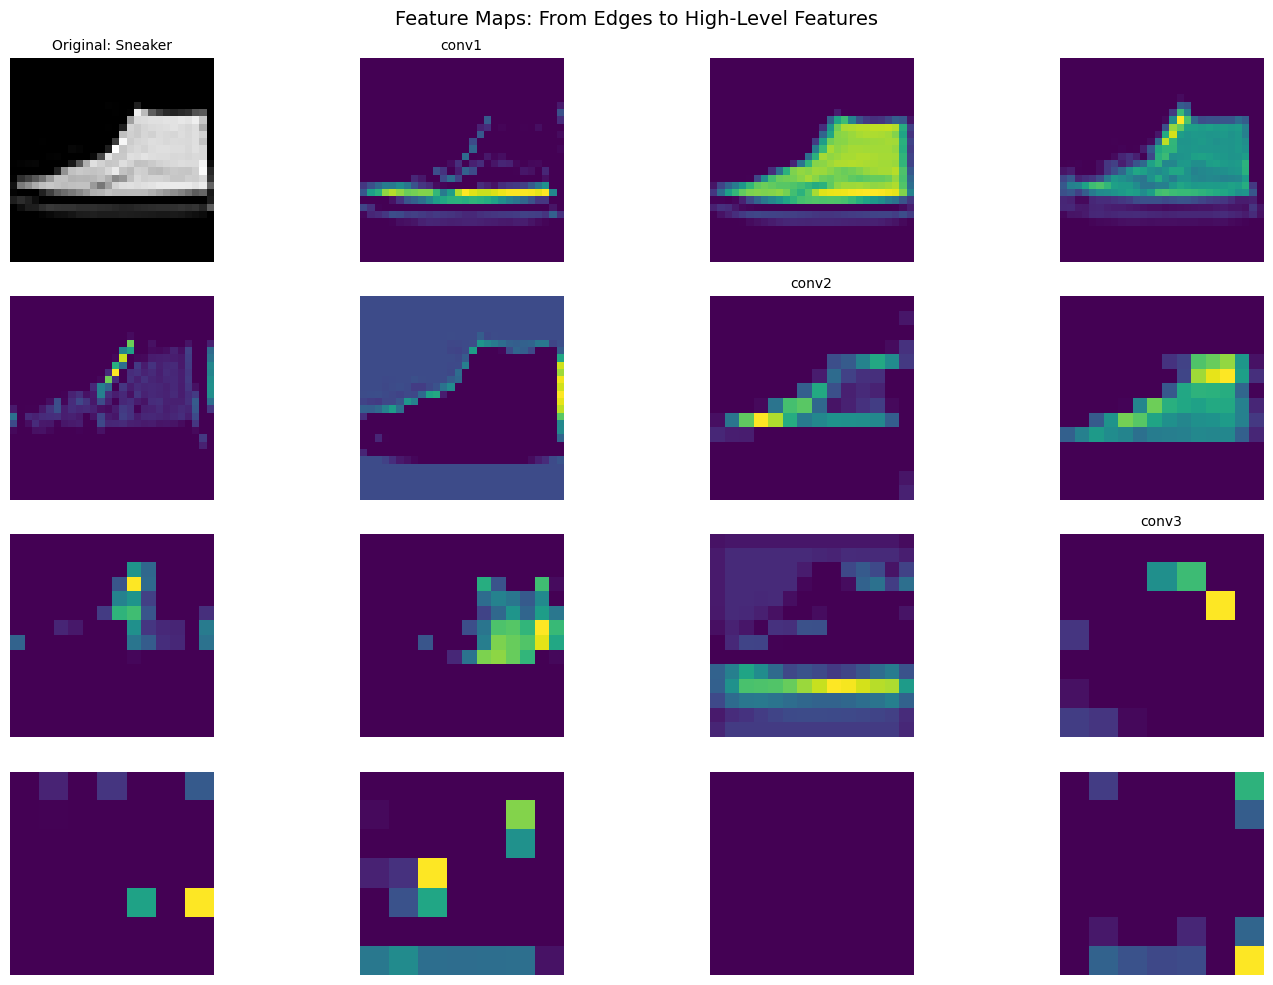

In [5]:
# Step 7: Create feature extraction model
def create_feature_extractor(model):
    layer_names = ['conv1', 'conv2', 'conv3']
    layer_outputs = [model.get_layer(name).output for name in layer_names]
    feature_extractor = Model(inputs=model.input, outputs=layer_outputs)
    return feature_extractor

feature_extractor = create_feature_extractor(model)

# Step 8: Visualize feature maps for a single image
def visualize_feature_maps(image, label, feature_extractor, layer_names=['conv1', 'conv2', 'conv3']):
    feature_maps = feature_extractor.predict(image[np.newaxis, ...], verbose=0)
    if not isinstance(feature_maps, list):
        feature_maps = [feature_maps]

    fig = plt.figure(figsize=(15, 10))
    # Plot original image
    plt.subplot(4, 4, 1)
    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f'Original: {class_names[label]}', fontsize=10)
    plt.axis('off')

    for layer_idx, (layer_name, features) in enumerate(zip(layer_names, feature_maps)):
        num_features = min(5, features.shape[-1])
        for i in range(num_features):
            plot_idx = layer_idx * 5 + i + 2
            if plot_idx <= 16:
                plt.subplot(4, 4, plot_idx)
                plt.imshow(features[0, :, :, i], cmap='viridis')
                plt.axis('off')
                if i == 0:
                    plt.title(f'{layer_name}', fontsize=10)

    for i in range(len(layer_names)*5 + 2, 17):
        plt.subplot(4, 4, i)
        plt.axis('off')

    plt.suptitle('Feature Maps: From Edges to High-Level Features', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

# Step 9: Demonstrate feature hierarchy
def demonstrate_feature_hierarchy(feature_extractor, test_images, test_labels, num_samples=2):
    print("\n" + "="*70)
    print("FEATURE HIERARCHY DEMONSTRATION")
    print("="*70)
    indices = np.random.choice(len(test_images), num_samples, replace=False)
    for idx in indices:
        image = test_images[idx]
        label = test_labels[idx]

        prediction = model.predict(image[np.newaxis, ...], verbose=0)
        pred_class = np.argmax(prediction)
        confidence = np.max(prediction)

        print(f"\nImage {idx}: True class = {class_names[label]}")
        print(f"Predicted: {class_names[pred_class]} (confidence: {confidence:.3f})")
        visualize_feature_maps(image, label, feature_extractor)

demonstrate_feature_hierarchy(feature_extractor, test_images, test_labels, num_samples=2)

## Comprehensive Summary and Saving


UNDERSTANDING CNN FEATURE HIERARCHY

    HOW CNNs LEARN HIERARCHICAL FEATURES:
    
    🔵 LAYER 1 (conv1) - LOW-LEVEL FEATURES:
       • Detects simple patterns like edges (horizontal, vertical, diagonal)
       • Identifies corners and basic textures
       • Output size: 14x14 with 32 channels
    
    🟢 LAYER 2 (conv2) - MID-LEVEL FEATURES:
       • Combines edges to form shapes (circles, rectangles, patterns)
       • Starts recognizing object parts (sleeves, collars, straps)
       • Output size: 7x7 with 64 channels
    
    🔴 LAYER 3 (conv3) - HIGH-LEVEL FEATURES:
       • Learns complex, task-specific features
       • Detects complete object parts and their arrangements
       • Output size: 3x3 with 128 channels
    


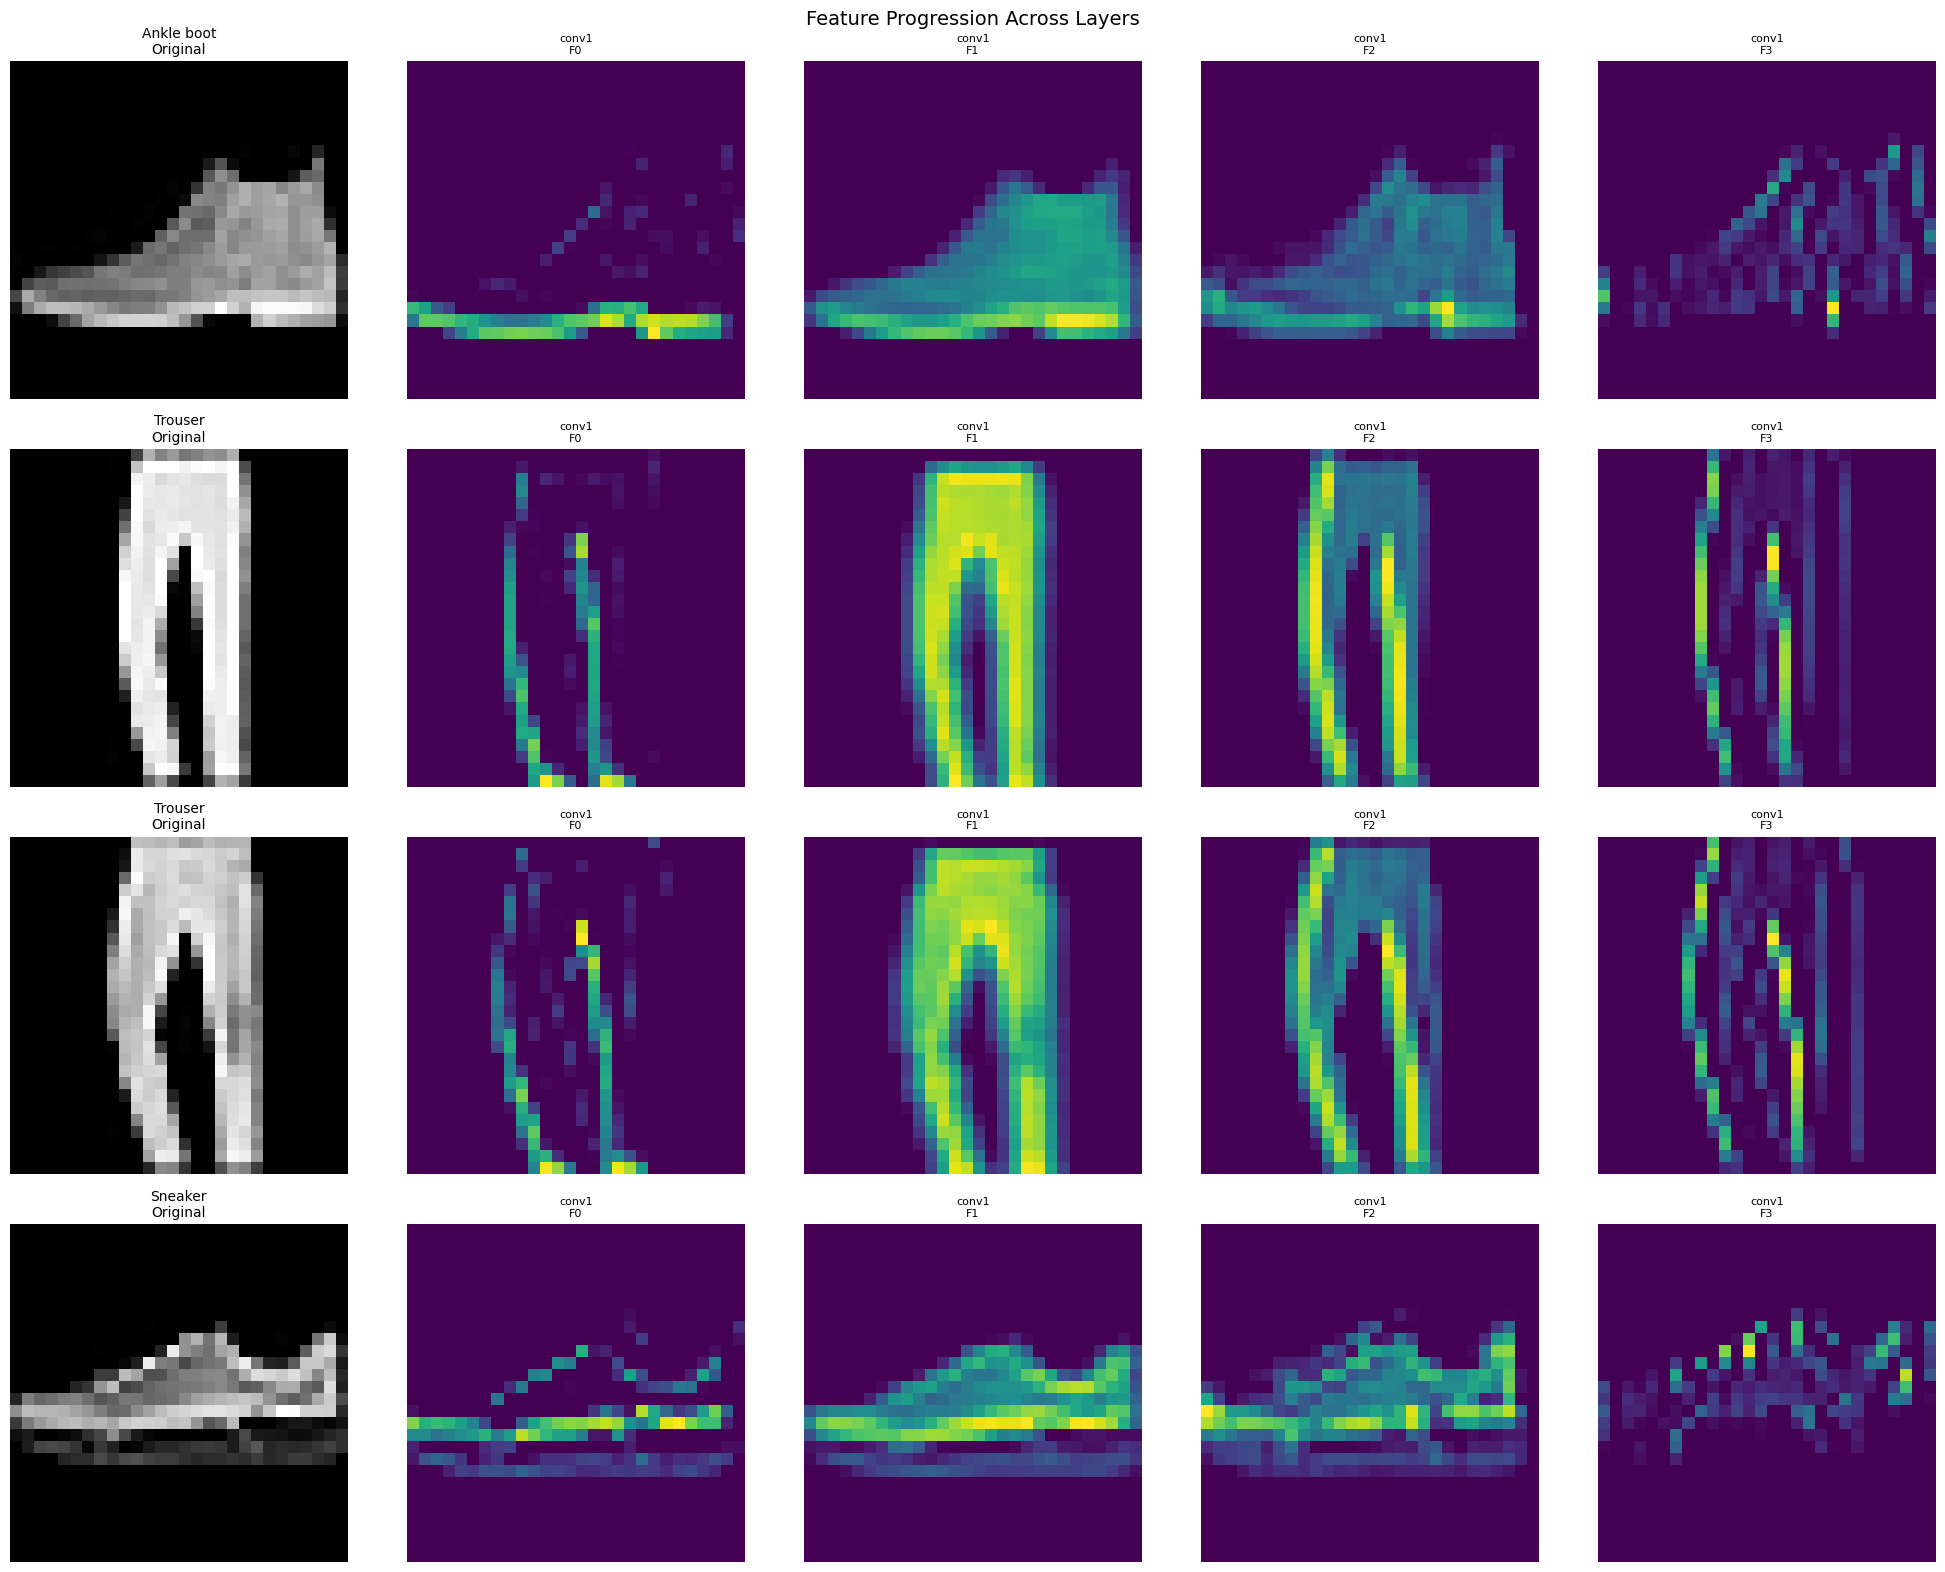


SUMMARY: CNN FEATURE LEARNING HIERARCHY
The network progressively builds more abstract and task-specific representations from raw pixels to final classification decisions.

Model saved as 'fashion_mnist_functional_model.h5'


In [6]:
# Step 13 & 14: Comprehensive feature hierarchy explanation & activations
def explain_feature_hierarchy_comprehensive(feature_extractor, test_images, test_labels):
    print("\n" + "="*80)
    print("UNDERSTANDING CNN FEATURE HIERARCHY")
    print("="*80)

    explanation = """
    HOW CNNs LEARN HIERARCHICAL FEATURES:

    🔵 LAYER 1 (conv1) - LOW-LEVEL FEATURES:
       • Detects simple patterns like edges (horizontal, vertical, diagonal)
       • Identifies corners and basic textures
       • Output size: 14x14 with 32 channels

    🟢 LAYER 2 (conv2) - MID-LEVEL FEATURES:
       • Combines edges to form shapes (circles, rectangles, patterns)
       • Starts recognizing object parts (sleeves, collars, straps)
       • Output size: 7x7 with 64 channels

    🔴 LAYER 3 (conv3) - HIGH-LEVEL FEATURES:
       • Learns complex, task-specific features
       • Detects complete object parts and their arrangements
       • Output size: 3x3 with 128 channels
    """
    print(explanation)

    example_indices = [0, 2, 5, 9]  # T-shirt, Pullover, Sandal, Ankle boot
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))

    for row, idx in enumerate(example_indices):
        image = test_images[idx]
        label = test_labels[idx]

        feature_maps = feature_extractor.predict(image[np.newaxis, ...], verbose=0)
        if not isinstance(feature_maps, list):
            feature_maps = [feature_maps]

        axes[row, 0].imshow(image.reshape(28, 28), cmap='gray')
        axes[row, 0].set_title(f'{class_names[label]}\nOriginal', fontsize=10)
        axes[row, 0].axis('off')

        for col, (layer_name, features) in enumerate(zip(['conv1', 'conv2', 'conv3'], feature_maps)):
            for f in range(min(4, features.shape[-1])):
                col_idx = col*4 + f + 1
                if col_idx < 5:
                  axes[row, col_idx].imshow(features[0, :, :, f], cmap='viridis')
                  axes[row, col_idx].set_title(f'{layer_name}\nF{f}', fontsize=8)
                  axes[row, col_idx].axis('off')

    plt.suptitle('Feature Progression Across Layers', fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

explain_feature_hierarchy_comprehensive(feature_extractor, test_images, test_labels)

# Step 15: Final summary & Save
print("\n" + "="*70)
print("SUMMARY: CNN FEATURE LEARNING HIERARCHY")
print("="*70)
print("The network progressively builds more abstract and task-specific representations from raw pixels to final classification decisions.")

# Save the model
model.save('fashion_mnist_functional_model.h5')
print("\nModel saved as 'fashion_mnist_functional_model.h5'")